# BERTopic Implementation: Preprocessing
Based on "BERTopic: Neural topic modeling with a class-based TF-IDF procedure"

This notebook handles the preprocessing of text data for BERTopic modeling, including:
- Loading datasets
- Text cleaning and normalization
- Lemmatization
- Stopword removal
- Filtering short documents
- Corpus statistics analysis

## 1. Setup and Dependencies

In [ ]:
# Install dependencies
!pip install -q spacy pandas scikit-learn tqdm matplotlib nltk
# !pip install gensim
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 94.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### Optional: Mount Google Drive
Uncomment and run if you want to access files from your Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import string
import re
import pandas as pd
import numpy as np
import spacy
from sklearn.datasets import fetch_20newsgroups
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import logging
from pathlib import Path
from google.colab import drive

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger('BERTopic-Preprocessing')

# Create data directories
#raw data is at /content/drive/MyDrive/DLFA_IIsc_AIML/capstone_project/data
# Path("data/raw").mkdir(parents=True, exist_ok=True)
processed_path = "data/processed/"
Path(processed_path).mkdir(parents=True, exist_ok=True)
data_path = "/content/drive/MyDrive/DLFA_IIsc_AIML/capstone_project/data/"


## 2. Load SpaCy Model

In [ ]:
# Load SpaCy model with only necessary components
logger.info("Loading SpaCy model...")
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "textcat"])

# Use spaCy's built-in stopwords
spacy_stopwords = spacy.lang.en.stop_words.STOP_WORDS
print(f"Loaded SpaCy model with {len(spacy_stopwords)} stopwords")

Loaded SpaCy model with 326 stopwords


## 3. Text Cleaning Functions

In [ ]:
def clean_text(text, min_word_length=2):
    """
    Clean and preprocess text data for topic modeling.

    Args:
        text (str): Input text to clean
        min_word_length (int): Minimum length of words to keep

    Returns:
        str: Cleaned text
    """
    if not isinstance(text, str) or pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Process with SpaCy (lemmatization + stopword removal in one pass)
    doc = nlp(text)

    # Get lemmatized tokens, skip stopwords and short words
    tokens = [
        token.lemma_
        for token in doc
        if (not token.is_stop and
            not token.lemma_ in spacy_stopwords and
            len(token.lemma_) >= min_word_length and
            token.lemma_ != "-PRON-" and  # Handle older spaCy versions
            not token.like_num)  # Skip numbers
    ]

    # Join tokens back into text
    cleaned_text = " ".join(tokens)

    # Remove extra whitespace
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

    return cleaned_text

# Test the cleaning function
test_text = "This is a sample text, with some punctuation! Numbers like 123 and 45.6 should be handled. Stopwords are removed."
print(f"Original: {test_text}")
print(f"Cleaned: {clean_text(test_text)}")

Original: This is a sample text, with some punctuation! Numbers like 123 and 45.6 should be handled. Stopwords are removed.
Cleaned: sample text punctuation number like handle stopword remove


In [ ]:
def process_dataset(df, text_column='document', batch_size=1000, min_words=5, temporal=False):

    logger.info(f"Processing dataset with {len(df)} documents")

    # Copy only necessary columns
    if temporal:
        # Identify timestamp column (first datetime column)
        date_cols = df.select_dtypes(include=['datetime64']).columns.tolist()
        if date_cols:
            timestamp_col = date_cols[0]
            new_df = df[[text_column, timestamp_col]].copy()
        else:
            # Try to identify date columns by name
            potential_date_cols = [col for col in df.columns if any(date_term in col.lower()
                                  for date_term in ['date', 'time', 'year', 'month', 'day'])]
            if potential_date_cols:
                timestamp_col = potential_date_cols[0]
                new_df = df[[text_column, timestamp_col]].copy()
            else:
                logger.warning("No timestamp column found for temporal dataset")
                new_df = df[[text_column]].copy()
                temporal = False
    else:
        new_df = df[[text_column]].copy()

    # Process in batches
    total_batches = (len(df) // batch_size) + (1 if len(df) % batch_size > 0 else 0)

    for i in tqdm(range(total_batches), desc="Processing batches"):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, len(df))

        batch = new_df.iloc[start_idx:end_idx].copy()
        batch['clean_text'] = batch[text_column].apply(clean_text)

        # Update the main dataframe
        new_df.loc[start_idx:end_idx, 'clean_text'] = batch['clean_text']

    # Filter by minimum word count
    original_count = len(new_df)
    new_df['word_count'] = new_df['clean_text'].str.split().str.len()
    new_df = new_df[new_df['word_count'] >= min_words]
    filtered_count = len(new_df)

    logger.info(f"Filtered out {original_count - filtered_count} documents ({(original_count - filtered_count) / original_count:.1%}) with fewer than {min_words} words")

    return new_df

## 4. Dataset Loading and Processing Functions

In [ ]:
def load_and_process_corpusText(filename,min_words=5):

    logger.info("Loading dataset...")
    # Check if we've already downloaded and cached it
    cache_path = data_path+filename
    print(cache_path)
    # # Initialize processed_df to None to avoid UnboundLocalError
    # processed_df = None  # Assign an initial value

    if os.path.exists(cache_path):
       # Load the corpus file (each line = one document)
       with open(cache_path, "r", encoding="utf-8") as f:
        documents = [line.strip() for line in f if line.strip()]

       # Create a DataFrame
       newsgroups_df = pd.DataFrame(documents, columns=["document"])

       # Optional: check first few rows
       print(newsgroups_df.head())
       logger.info("Loaded from path")

       # Process the text
       processed_df = process_dataset(newsgroups_df, min_words=min_words)

    # Save processed data
    processed_filename=processed_path + filename + ".csv"
    logger.info(f"Saving processed data to {processed_filename}")
    processed_df.to_csv(processed_filename, index=False)
    logger.info(f"Saved processed 20 Newsgroups dataset ({len(processed_df)} documents)")

    return processed_df

#test function
# Process 20 Newsgroups dataset
# news20_file="20NewGroup_minfLab_corpus.txt"  # Update with your file name
# news_df = load_and_process_corpusText(news20_file)

# # Display the first few rows
# display(news_df.head())


In [ ]:
def load_and_process_custom_dataset(file_path, text_column='text', min_words=5, temporal=False):
    """Load and process a custom dataset from CSV"""
    if not os.path.exists(file_path):
        logger.error(f"File not found: {file_path}")
        return None

    logger.info(f"Loading dataset from {file_path}")

    try:
        # Try to infer date columns
        df = pd.read_csv(file_path, parse_dates=True, infer_datetime_format=True)
        logger.info(f"Loaded dataset with {len(df)} rows and {len(df.columns)} columns")

        # Verify the text column exists
        if text_column not in df.columns:
            logger.error(f"Text column '{text_column}' not found in dataset")
            logger.info(f"Available columns: {', '.join(df.columns)}")
            return None

        # Process the dataset
        processed_df = process_dataset(df, text_column=text_column, min_words=min_words, temporal=temporal)

        # Generate output filename
        output_name = os.path.splitext(os.path.basename(file_path))[0] + "_processed.csv"
        output_path = os.path.join("data/processed", output_name)

        # Save processed data
        processed_df.to_csv(output_path, index=False)
        logger.info(f"Saved processed dataset to {output_path} ({len(processed_df)} documents)")

        return processed_df

    except Exception as e:
        logger.error(f"Error processing {file_path}: {str(e)}")
        return None

## 5. Corpus Analysis Functions

In [ ]:
def analyze_corpus(df, filename, text_column='clean_text'):
    """Generate and plot statistics about the corpus"""
    if len(df) == 0:
        logger.warning("Empty dataframe, skipping analysis")
        return

    # Document length statistics
    df['doc_length'] = df[text_column].str.split().str.len()
    avg_length = df['doc_length'].mean()
    median_length = df['doc_length'].median()

    logger.info(f"Corpus statistics:")
    logger.info(f"  Documents: {len(df)}")
    logger.info(f"  Average document length: {avg_length:.1f} words")
    logger.info(f"  Median document length: {median_length:.1f} words")

    # Vocabulary statistics
    all_words = ' '.join(df[text_column]).split()
    vocab_size = len(set(all_words))
    logger.info(f"  Total vocabulary size: {vocab_size} unique words")
    logger.info(f"  Total word count: {len(all_words)} words")

    # Plot document length distribution
    plt.figure(figsize=(10, 6))
    plt.hist(df['doc_length'], bins=50, alpha=0.7)
    plt.axvline(avg_length, color='r', linestyle='--', label=f'Mean: {avg_length:.1f}')
    plt.axvline(median_length, color='g', linestyle='--', label=f'Median: {median_length:.1f}')
    plt.xlabel('Document Length (words)')
    plt.ylabel('Frequency')
    plt.title('Document Length Distribution')
    plt.legend()
    plt.tight_layout()

    # Save figure
    figure_file = processed_path + filename + "_doc_length_distribution.png"
    logger.info(f"Saving document length distribution figure to {figure_file}")
    plt.savefig(figure_file)
    plt.show()

    # Return statistics
    return {
        'doc_count': len(df),
        'avg_length': avg_length,
        'median_length': median_length,
        'vocab_size': vocab_size,
        'total_words': len(all_words)
    }

## 6. Process 20 Newsgroups Dataset (Demo)

In [ ]:
# # Process 20 Newsgroups dataset
# news20_file="20NewGroup_minfLab_corpus.txt"  # Update with your file name
# news_df = load_and_process_corpusText(news20_file)

# # Display the first few rows
# display(news_df.head())

# # Analyze the corpus
# news_stats = analyze_corpus(news_df, news20_file)

## 7. Process Custom Datasets

Uncomment and edit the sections below to process your own datasets.

In [ ]:
# # Process BBC News dataset (static)
# bbc_file = "bbc_news_mindLab_corpus.txt"  # Update with your file path
# # Process 20 Newsgroups dataset
# bbc_df = load_and_process_corpusText(bbc_file)

# # Display the first few rows
# display(bbc_df.head())

# # Analyze the corpus
# bbc_stats = analyze_corpus(bbc_df, bbc_file)

In [ ]:
# Process Trump Tweets dataset (temporal)
# tweets_path = data_path+"tweets_01-08-2021.csv"  # Update with your file path
# if os.path.exists(tweets_path):
#     print(f"Processing Trump Tweets dataset from {tweets_path}")
#     tweets_df = load_and_process_custom_dataset(
#         tweets_path,
#         text_column='text',
#         min_words=5,
#         temporal=True
#     )
#     if tweets_df is not None:
#         display(tweets_df.head())
#         tweets_stats = analyze_corpus(tweets_df)
# else:
#     print(f"Trump Tweets dataset not found at {tweets_path}")

Processing phone dataset from /content/drive/MyDrive/DLFA_IIsc_AIML/capstone_project/data/iphone.csv


<ipython-input-8-06a43b1ea900>:11: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(file_path, parse_dates=True, infer_datetime_format=True)


Processing batches:   0%|          | 0/4 [00:00<?, ?it/s]

,reviewDescription,date,clean_text,word_count
0,"Every thing is good about iPhones, there's not...",11-08-2024,thing good iphone compare speed io disappoint ...,26
1,"It look so fabulous, I am android user switche...",16-08-2024,look fabulous android user switch apple perfor...,18
2,I tried to flip camera while recording but no ...,14-05-2024,try flip camera record facility add pause flip...,34
6,"Great Product... Nothing to say, as the Name A...",28-01-2024,great product apple identity product recommend...,9
10,My honest review after going broke buying this...,06-02-2022,honest review break buy depreciate objecti and...,212


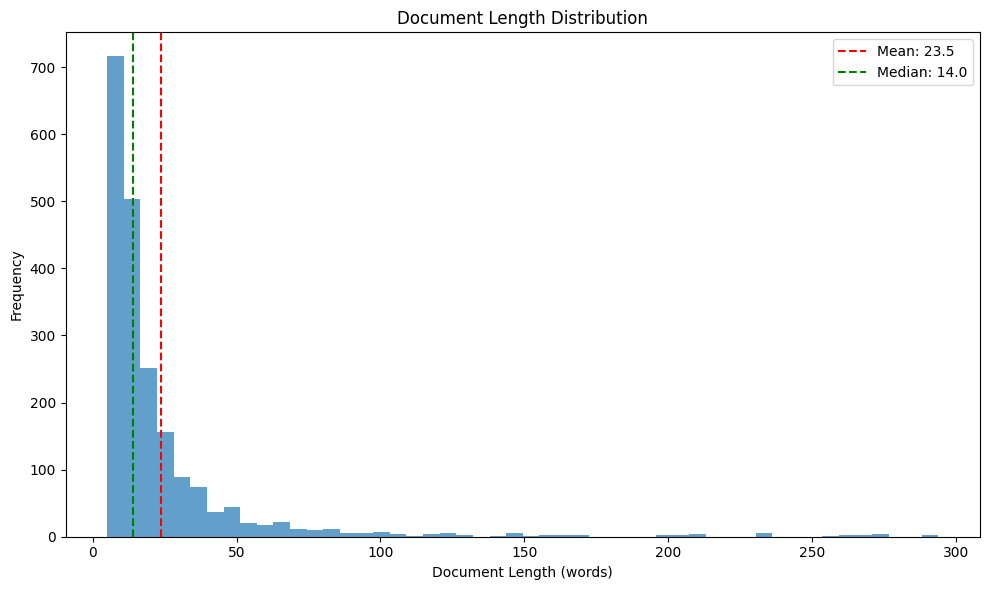

In [ ]:
#Process phone datasets
filename="iphone.csv"
phone_data_path = data_path + filename  # Update with your file path
if os.path.exists(phone_data_path):
    print(f"Processing phone dataset from {phone_data_path}")
    phone_df = load_and_process_custom_dataset(
        phone_data_path,
        text_column='reviewDescription',
        min_words=5,
        temporal=True
    )
    if phone_df is not None:
        display(phone_df.head())
        phone_stats = analyze_corpus(phone_df,filename)
else:
    print(f"Phone dataset not found at {phone_data_path}")

## 8. Process UN Debates Dataset (Optional)

In [ ]:
# # Process UN Debates dataset (temporal)
# debates_path = data_path+"un-general-debates.csv"  # Update with your file path
# if os.path.exists(debates_path):
#     print(f"Processing UN Debates dataset from {debates_path}")
#     debates_df = load_and_process_custom_dataset(
#         debates_path,
#         text_column='text',
#         min_words=5,
#         temporal=True
#     )
#     if debates_df is not None:
#         display(debates_df.head())
#         debates_stats = analyze_corpus(debates_df,debates_path)
# else:
#     print(f"UN Debates dataset not found at {debates_path}")

Processing UN Debates dataset from /content/drive/MyDrive/DLFA_IIsc_AIML/capstone_project/data/un-general-debates.csv


<ipython-input-8-06a43b1ea900>:11: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(file_path, parse_dates=True, infer_datetime_format=True)


Processing batches:   0%|          | 0/8 [00:00<?, ?it/s]

,text,year,clean_text,word_count
0,﻿It is indeed a pleasure for me and the member...,1989,﻿it pleasure member delegation extend ambassad...,1427
1,"﻿\nMay I begin by congratulating you. Sir, on ...",1989,begin congratulate sir election presidency gen...,1303
2,"﻿\nMr. President, it is a particular pleasure ...",1989,mr president particular pleasure behalf delega...,2329
3,﻿\nDuring the debate at the fortieth session o...,1989,debate session general assembly year ago presi...,1268
4,﻿I should like at the outset to express my del...,1989,﻿i like outset express delegation satisfaction...,2053


TypeError: analyze_corpus() missing 1 required positional argument: 'filename'

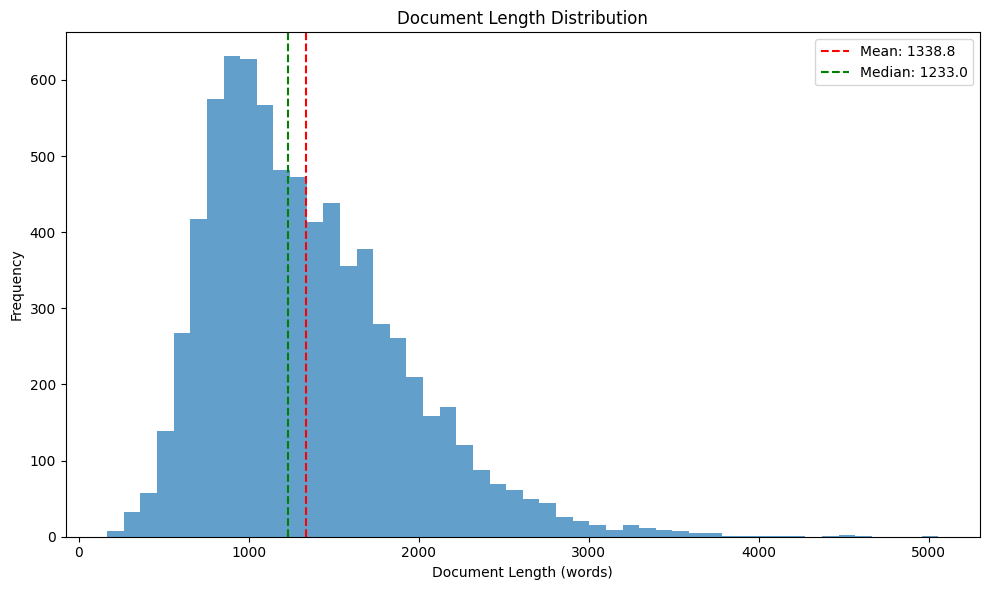

In [ ]:
# debates_stats = analyze_corpus(debates_df,"un-general-debates_plot")

## 9. Conclusion

This notebook has processed the following datasets:
1. 20 Newsgroups (static)

The processed data is saved in the `data/processed/` directory and is ready for the next step in the BERTopic pipeline (embedding generation).

Key statistics:
- Total documents processed: {Include count here}
- Average document length: {Include average here} words
- Vocabulary size: {Include size here} unique words

In [ ]:
# Summary of processed datasets
print("\nPreprocessing complete!")
print("\nProcessed datasets:")
print("- 20 Newsgroups: {} documents".format(len(news_df) if 'news_df' in locals() else "Not processed"))

print("- BBC News: {} documents".format(len(bbc_df) if 'bbc_df' in locals() else "Not processed"))
print("- Trump Tweets: {} documents".format(len(tweets_df) if 'tweets_df' in locals() else "Not processed"))
print("- UN Debates: {} documents".format(len(debates_df) if 'debates_df' in locals() else "Not processed"))
print("- Phone Debates: {} documents".format(len(phone_df) if 'phone_df' in locals() else "Not processed"))

print("\nAll preprocessed data saved to 'data/processed/' directory.")


Preprocessing complete!

Processed datasets:
- 20 Newsgroups: Not processed documents
- BBC News: Not processed documents
- Trump Tweets: Not processed documents
- UN Debates: 7507 documents

All preprocessed data saved to 'data/processed/' directory.


#OCTIS Dataset Format
OCTIS expects a folder (e.g., ./octis_dataset/) with the following:

In [2]:
processed_data_path = "/content/drive/MyDrive/DLFA_IIsc_AIML/capstone_project/data_processed/" #set data path here
model_path="/content/drive/MyDrive/DLFA_IIsc_AIML/capstone_project/model/"
data_name = "phone_data"
#data_path = "/content/drive/MyDrive/DLFA_IIsc_AIML/capstone_project/data/"

In [5]:
#load data phone
phone_file = processed_data_path + "iphone_processed.csv"
df = pd.read_csv(phone_file)  # adjust the path
docs = df['clean_text'].dropna().tolist()  # adjust column name as needed

In [6]:
# Print first 5 cleaned documents
for i, doc in enumerate(docs[:5]):
    print(f"Document {i+1}:\n{doc}\n{'-'*40}")


Document 1:
thing good iphone compare speed io disappoint charger indian judiciary tell provide progress charger spend 62k iphone brand acessorie comfort size feature right point buy iphonethank
----------------------------------------
Document 2:
look fabulous android user switch apple performance wise iphone android a15 bionic chip feel pleasant iphone hand like
----------------------------------------
Document 3:
try flip camera record facility add pause flip vice versa mean continue awkward position iphone software upgrade essential content creator purchase gimbal dji om se provide essential vlogger feed find basic requirement build product
----------------------------------------
Document 4:
great product apple identity product recommendation grab product miss
----------------------------------------
Document 5:
honest review break buy depreciate objecti android phone year finally decide switch iphone roast iphone price lack feature thing like power adapter box etc android phone i

In [11]:
import nltk

# Download full punkt tokenizer model
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [12]:
import os
import json
from nltk.tokenize import word_tokenize

def prepare_octis_dataset(df, output_dir="octis_dataset"):
    os.makedirs(output_dir, exist_ok=True)

    # Tokenized documents
    tokenized_docs = df["clean_text"].apply(lambda x: word_tokenize(x.lower())).tolist()

    # Save data.json
    with open(os.path.join(output_dir, "data.json"), "w") as f:
        json.dump(tokenized_docs, f)

    # Save vocabulary.txt
    vocab = sorted(set(word for doc in tokenized_docs for word in doc))
    with open(os.path.join(output_dir, "vocabulary.txt"), "w") as f:
        for word in vocab:
            f.write(f"{word}\n")

In [13]:
prepare_octis_dataset(df, output_dir=processed_data_path+"octis_dataset")